In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df=pd.read_csv('..//Data/Cleaned_Data.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Relative_Compactness  768 non-null    float64
 1   Wall_Area             768 non-null    float64
 2   Roof_Area             768 non-null    float64
 3   Overall_Height        768 non-null    float64
 4   Orientation           768 non-null    int64  
 5   Glazing_Area          768 non-null    float64
 6   Glazing_Distribution  768 non-null    int64  
 7   Heating_Load          768 non-null    float64
 8   Cooling_Load          768 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


In [ ]:
#Need to dummy the categorical columns
df = pd.get_dummies(df, columns=['Overall_Height'],prefix="H", drop_first=True)
df = pd.get_dummies(df, columns=['Orientation'],prefix="Ori", drop_first=True)
df = pd.get_dummies(df, columns=['Glazing_Area'],prefix="GA", drop_first=True)
df = pd.get_dummies(df, columns=['Glazing_Distribution'],prefix="GD",drop_first=True)

In [ ]:
#To verify the dummies, and to check the columns name
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Relative_Compactness  768 non-null    float64
 1   Wall_Area             768 non-null    float64
 2   Roof_Area             768 non-null    float64
 3   Heating_Load          768 non-null    float64
 4   Cooling_Load          768 non-null    float64
 5   H_7.0                 768 non-null    bool   
 6   Ori_3                 768 non-null    bool   
 7   Ori_4                 768 non-null    bool   
 8   Ori_5                 768 non-null    bool   
 9   GA_0.1                768 non-null    bool   
 10  GA_0.25               768 non-null    bool   
 11  GA_0.4                768 non-null    bool   
 12  GD_1                  768 non-null    bool   
 13  GD_2                  768 non-null    bool   
 14  GD_3                  768 non-null    bool   
 15  GD_4                  768 non-null

In [ ]:
#TrainTestSplit
X = df.drop(columns=["Heating_Load","Cooling_Load"])
Y= df[["Heating_Load","Cooling_Load"]]
XN = ['Relative_Compactness','Wall_Area',"Roof_Area"]
XD = ['H_7.0','Ori_3','Ori_4','Ori_5','GA_0.1','GA_0.25','GA_0.4','GD_1',"GD_2",'GD_3','GD_4','GD_5']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state=42)
#Enable Scaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[XN]=scaler.fit_transform(X_train[XN])
X_test_scaled[XN]=scaler.transform(X_test[XN])
#running LinearRegression 
lrh = LinearRegression() #lrh for Heating
lrh.fit(X_train_scaled, Y_train["Heating_Load"])
y_predh=lrh.predict(X_test_scaled)
lrc = LinearRegression() #lrc for Cooling
lrc.fit(X_train_scaled, Y_train["Cooling_Load"])
y_predc=lrc.predict(X_test_scaled)
#Calculate the evaluations 
rmse_h =round(np.sqrt(mean_squared_error(Y_test['Heating_Load'], y_predh)), 2)
r2_h = round(r2_score(Y_test['Heating_Load'], y_predh), 2)
mse_h = round(mean_squared_error(Y_test['Heating_Load'], y_predh),2)

rmse_c =round(np.sqrt(mean_squared_error(Y_test['Cooling_Load'], y_predc)), 2)
r2_c = round(r2_score(Y_test['Cooling_Load'], y_predc), 2)
mse_c = round(mean_squared_error(Y_test['Cooling_Load'], y_predc),2)
#to print the metrics in a reader friendly way
print("Heating Load")
print(f"RMSE: {rmse_h}, R2: {r2_h}, MSE: {mse_h}")
print("Cooling Load")
print(f"RMSE: {rmse_c}, R2: {r2_c}, MSE: {mse_c}")

Heating Load
RMSE: 2.88, R2: 0.92, MSE: 8.27
Cooling Load
RMSE: 3.12, R2: 0.89, MSE: 9.76


The Heating Model covers 92% of variance, while the Cooling covers 89%.
The Heating prediction can be off by 2.88, while cooling is 3.12. (Plus or Minus)
Both reading seems to be very predictive and with hhigh level of precise. 

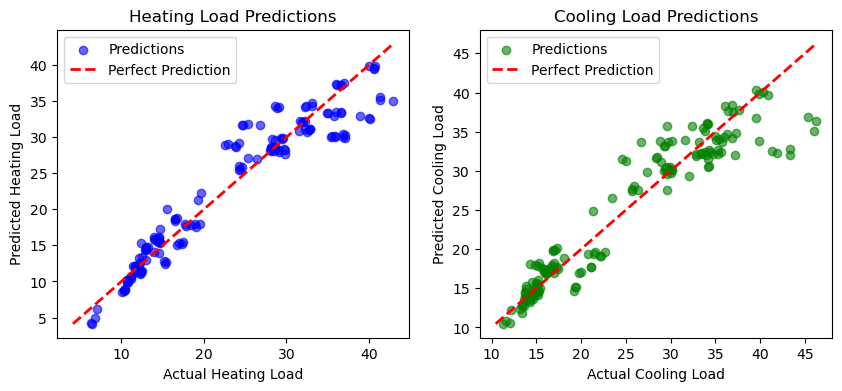

In [10]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
# Heating Model
ax = axes[0]
ax.scatter(Y_test['Heating_Load'], y_predh, color='blue', alpha=0.6, label='Predictions')
min_val = min(Y_test['Heating_Load'].min(), y_predh.min())
max_val = max(Y_test['Heating_Load'].max(), y_predh.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Heating Load')
ax.set_ylabel('Predicted Heating Load')
ax.set_title('Heating Load Predictions')
ax.legend()

# Cooling Model
ax = axes[1]
ax.scatter(Y_test['Cooling_Load'], y_predc, color='green', alpha=0.6, label='Predictions')
min_val = min(Y_test['Cooling_Load'].min(), y_predc.min())
max_val = max(Y_test['Cooling_Load'].max(), y_predc.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Cooling Load')
ax.set_ylabel('Predicted Cooling Load')
ax.set_title('Cooling Load Predictions')
ax.legend()

plt.show()